<font size = 1 color="gray">Introducción a la programación científica</font>  

<img src="img/logo-vector-u-tad-iprc.jpg" align="left" >

# 8. Aplicaciones


## Calculo de momentos de inercia

Sabemos que el momento de inercia de un cuerpo sólido es $ \int x^2\,dm$, donde $x$ es la distancia al eje de rotación. La solución de la integral es posible en cuerpos geométricos con algún tipo de simetría. Por ejemplo, el momento de inercia de una barra de longitud $L$, espesor despreciable y densidad constante respecto a un eje vertical en su punto medio es:

$I_c = \int_{-L/2}^{L/2} x^2 dm$, como la densidad es constante podemos escribir que $dm = \frac{M}{L}\,dx$ y la integral es, en definitiva:

$I_c = \int_{-L/2}^{L/2} \frac{M}{L}\,x^2dx = \frac{ML^2}{12} \, \tiny{[Kg\, m^2]}$

Para un conjunto de partículas, la integral se convierte en la suma $I_c = \sum x_{i}^2 m_{i}$. Podemos obtener una aproximación del momento de inercia de un sólido por el método Monte-Carlo, distribuyendo aleatoriamente partículas puntuales y calculando el momento de inercia del conjunto.

Para el caso de la barra, repartimos de forma uniforme al azar $N$ puntos, a cada cual asignamos una masa $\frac{M}{N}$ y calcularemos su momento de inercia como la suma de los momentos de inercia de todas esas partículas.


10	I autentico:  0.3333	I calculado:  0.4405
100	I autentico:  0.3333	I calculado:  0.2920
1000	I autentico:  0.3333	I calculado:  0.3375
10000	I autentico:  0.3333	I calculado:  0.3338
100000	I autentico:  0.3333	I calculado:  0.3329


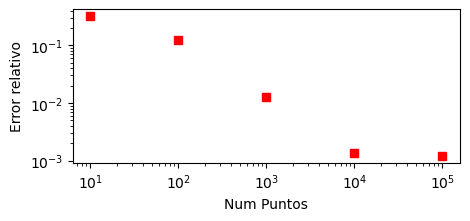

In [7]:
import numpy as np
import matplotlib.pyplot as plt
M= 1 # Kg
L = 2 # m
errors = list()
Iautentico = M*L**2/12
NumP = [10,100,1000,10000,100000] # número de partículas
for N in NumP:
    x_particulas = np.random.uniform(-L/2,L/2,N)
    Icalculado = sum(x_particulas**2*M/N)
    error=abs(Icalculado-Iautentico)/Iautentico
    errors.append(error)
    print("%d\tI autentico:  %.4f\tI calculado:  %.4f" % (N,Iautentico,Icalculado))
    
plt.figure(figsize=(5,2))
plt.plot(NumP, errors, 'rs')
plt.xscale('log')
plt.xlabel("Num Puntos")
plt.yscale('log')
plt.ylabel("Error relativo")
plt.show()

Calcular el momento de inercia de la misma barra si el eje de rotación está en uno de sus extremos. En esta situación, podemos calcular la integral o aplicar el [teorema de Steiner](https://es.wikipedia.org/wiki/Teorema_del_eje_paralelo) : dado un eje que pasa por el centro de masa de un sólido y un segundo eje paralelo al primero, el momento de inercia de ambos ejes está relacionado mediante la expresión:

$I_{x} = I_{c} + mx^{2}$

donde $I_{c}$ es el momento de inercia respecto del eje del centro de masas, $m$ la masa del sólido y $x$ la distancia del eje parelo. Para la barra tendremos que:

$I_{x} = \frac{ML^2}{12} + M(\frac{L}{2})^{2} = \frac{ML^2}{12} + M(\frac{L^2}{4}) = \frac{ML^2}{3}$ 

Hacemos ahora el cálculo por el método de Monte Carlo y sin aplicar el teorema de Steiner, únicamente tenemos en cuenta que la distancia de las partículas está entre 0 y $L$

10	I autentico:  1.3333	I calculado:  1.6686
100	I autentico:  1.3333	I calculado:  1.3462
1000	I autentico:  1.3333	I calculado:  1.3130
10000	I autentico:  1.3333	I calculado:  1.3488
100000	I autentico:  1.3333	I calculado:  1.3320


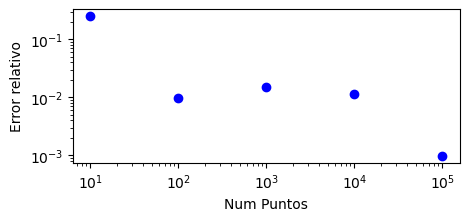

In [8]:
errors = list()
Iautentico = M*L**2/3
for N in NumP:
    x_particulas = np.random.uniform(0,L,N)
    Icalculado = sum(x_particulas**2*M/N)
    error=abs(Icalculado-Iautentico)/Iautentico
    errors.append(error)
    print("%d\tI autentico:  %.4f\tI calculado:  %.4f" % (N,Iautentico,Icalculado))
    
plt.figure(figsize=(5,2))
plt.plot(NumP, errors, 'bo')
plt.xscale('log')
plt.xlabel("Num Puntos")
plt.yscale('log')
plt.ylabel("Error relativo")
plt.show()

## Resorte/amortiguador vertical

Simulamos una masa colgada de un resorte, sometida únicamente a la gravedad y apoyada en un amortiguador que ejerce fuerza de dirección opuesta a la del muelle y proporcional a la velocidad de la masa. Este tipo de montaje es el que se utiliza en la suspensión de los automóviles para reducir las vibraciones producidas por el contacto con la superficie de la carretera.

Si la vibración se reduce de forma muy brusca, el automóvil y los pasajeros sufren las consecuencias. Si, por el contrario, apenas hay amortiguamiento la experiencia del viaje es muy desagradable. Esto ocurre cuando el amortiguador se desgasta.

Si la única fuerza exterior es la gravedad, que actúa sobre la masa del vehículo, la EDO del sistema es:

$m\ddot{x} + c\dot{x} + kx + mg = 0$

Que podemos reescribir como un sistema de ecuaciones de primer orden acopladas:

$v = \frac{dx}{dt}, \\
\frac{dv}{dt} = -\frac{k}{m} x - \frac{k}{m} v - \frac{g}{m}$

<div>
<br>
    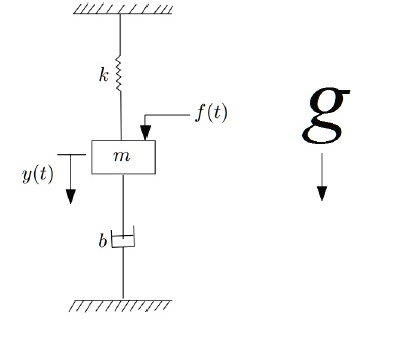
</div>

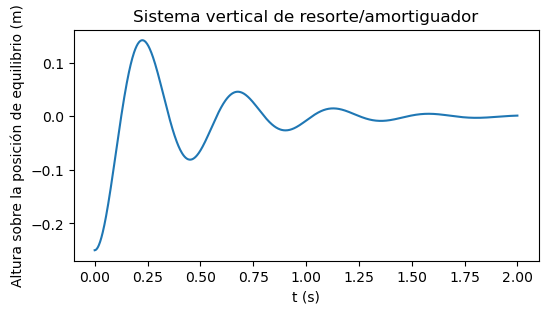

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def EDO_resorte_amortiguador(y, t, k, m, c):
    """
    y[0] = pos, y[1] = vel
    """
    g = 9.81
    pos, vel = y
    dydt = [vel, (-k/m * pos) - (c/m * vel) - g/m]
    return dydt

m = 1.0e3     # Masa kg
k = 200e3     # Constante del resorte N/m
c = 5e3       # Coeficiente de amortiguacion in Ns/m

# Initial conditions
x0 = -0.25  # Posición inicial de la masa, por debajo del equilibrio. Bache de 25 cm
v0 = 0  # Velocidad vertical inicial en m/s

# Time points for simulation
t = np.linspace(0, 2, 1000)  # tiempo

# Solve the ODE using odeint
condiciones_iniciales = [x0, v0]
solucion = odeint(EDO_resorte_amortiguador, condiciones_iniciales, t, args=(k, m, c))

# Extract position and velocity from the solution
x = solucion[:, 0]
v = solucion[:, 1]

# Plot the position and velocity over time
plt.figure(figsize=(6, 3))
plt.plot(t, x)
plt.xlabel('t (s)')
plt.ylabel('Altura sobre la posición de equilibrio (m)')
plt.title('Sistema vertical de resorte/amortiguador')

#plt.subplot(2, 1, 2)

plt.show()

## Circuito RLC forzado

El circuito RLC forzado, consta de los tres componentes R, L y C, alimentados por una señal, que puede ser o no periódica. El ejemplo más habitual es utilizando un generador senoidal.

La corriente que circula por el circuito es:

$Ri(t) + L \frac{di(t)}{dt} + \frac{Q(t)}{C}  = V(t)$

Y para este caso $i(t)=\frac{dQ(t)}{dt}$. Este par de ecuaciones acopladas permiten simular numéricamente la evolución tanto de la corriente como de la carga, con la ventaja de que $V(t)$ puede tomar cualquier forma, no necesariamente senoidal. En la imagen, tomada de [Física Universitaria, Vol. 2 openstax](https://openstax.org/details/books/f%C3%ADsica-universitaria-volumen-2), pueden verse la tensión del generadory la corriente (desfasada).

La frecuencia de resonancia de este circuito es $\frac{1}{2\pi\sqrt{LC}}$

<div>
<br>
    <img src="img/RLC.png" width="500">
</div>

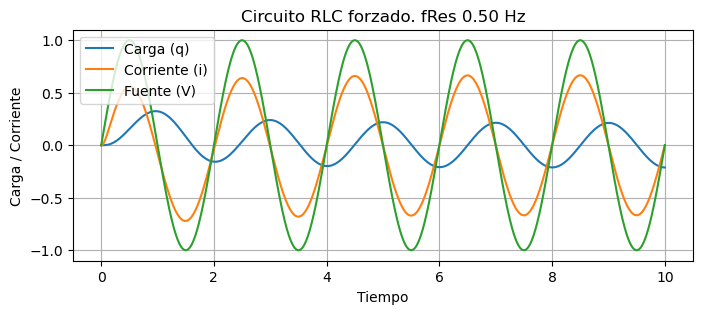

In [10]:
# Parámetros del circuito [Ficticios]
R = 1.5  # Resistencia (Ohms)
L = 0.1   # Inductancia (H)
C = 1  # Capacitancia (F)
V = 1   # Amplitud de la señal de la fuente (V)
frec = 0.5 # Frecuencia de la fuente

# Frecuencia de resonancia
fres = 1/2*np.pi*np.sqrt(L*C)
# Condiciones iniciales
q0 = 0.0  # Carga inicial del condensador
i0 = 0.0  # Corriente inicial

# Parámetros de tiempo
t_start = 0
t_end = 10
puntos = 1000
dt = (t_end-t_start)/puntos  # Time step

# Inicialización
num_steps = int((t_end - t_start) / dt) + 1
time_values = np.linspace(t_start, t_end, num_steps)
V_values = V*np.sin(2*np.pi*frec*time_values)

def ResolverCircuito(q0,i0,num_steps,R,L,C,V_values):
# Integración numérica por el método de Euler
    q_values = np.zeros(num_steps)
    i_values = np.zeros(num_steps)
    q = q0
    i = i0
    for step in range(num_steps):
        q_values[step] = q
        i_values[step] = i    
        dqdt = i
        q += dqdt * dt
        didt = (V_values[step] - q/C - R*i) / L
        i += didt * dt
    return q_values, i_values

# Resultados
def Graficar(time_values,q_values,i_values,V_values):
    plt.figure(figsize=(8,3))
    plt.plot(time_values, q_values, label='Carga (q)')
    plt.plot(time_values, i_values, label='Corriente (i)')
    plt.plot(time_values, V_values, label='Fuente (V)')
    plt.xlabel('Tiempo')
    plt.ylabel('Carga / Corriente')
    plt.title("Circuito RLC forzado. fRes %.2f Hz" % fres)
    plt.legend()
    plt.grid()
    plt.show()
    
q_values, i_values = ResolverCircuito(q0,i0,num_steps,R,L,C,V_values)
Graficar(time_values,q_values,i_values,V_values)

Podemos representar la tensión en la resistencia frente a la tensión en la bobina con una figura de Lissajous
que es muy habitual al medir con un osciloscopio.

$V_{R}(t)=Ri(t)$ y $V_{L}(t)=L\frac{dI}{dt}$

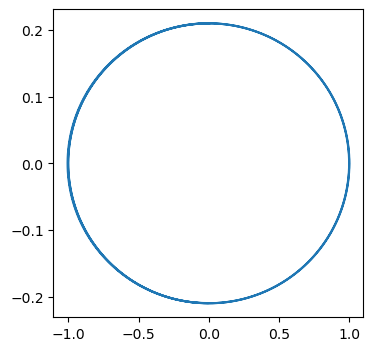

In [11]:
def Lissajous():
    VR_values = R*i_values
    VL_values = L*np.gradient(i_values,dt)  # np.gradient calcula la derivada por el método de diferencias finitas
    return VR_values[int(puntos*0.5):], VL_values[int(puntos*0.5):] # Régimen permanente
VR, VL = Lissajous()
plt.figure(figsize=(4,4))
plt.plot(VR, VL)
plt.show()

Una representación muy habitual son las figuras de Lissajous, que se obtienen, midiendo con un osciloscopio dos magnitudes. Por ejemplo, podemos representar en uno de los ejes la tensión en el resistor y en el otro la tensión en la bobina. Sabemos que:

$V_{R}(t)= Ri(t), V_{L}=L$

El circuito RLC serie es un filtro paso bajo, en el que las frecuencias por encima de la de resonancia son eliminadas (¡descripción muy burda!).

Vamos a hacer la prueba de alimentar el mismo circuito con una onda que es suma de dos sinusoides de frecuencias dispares.

<div>
   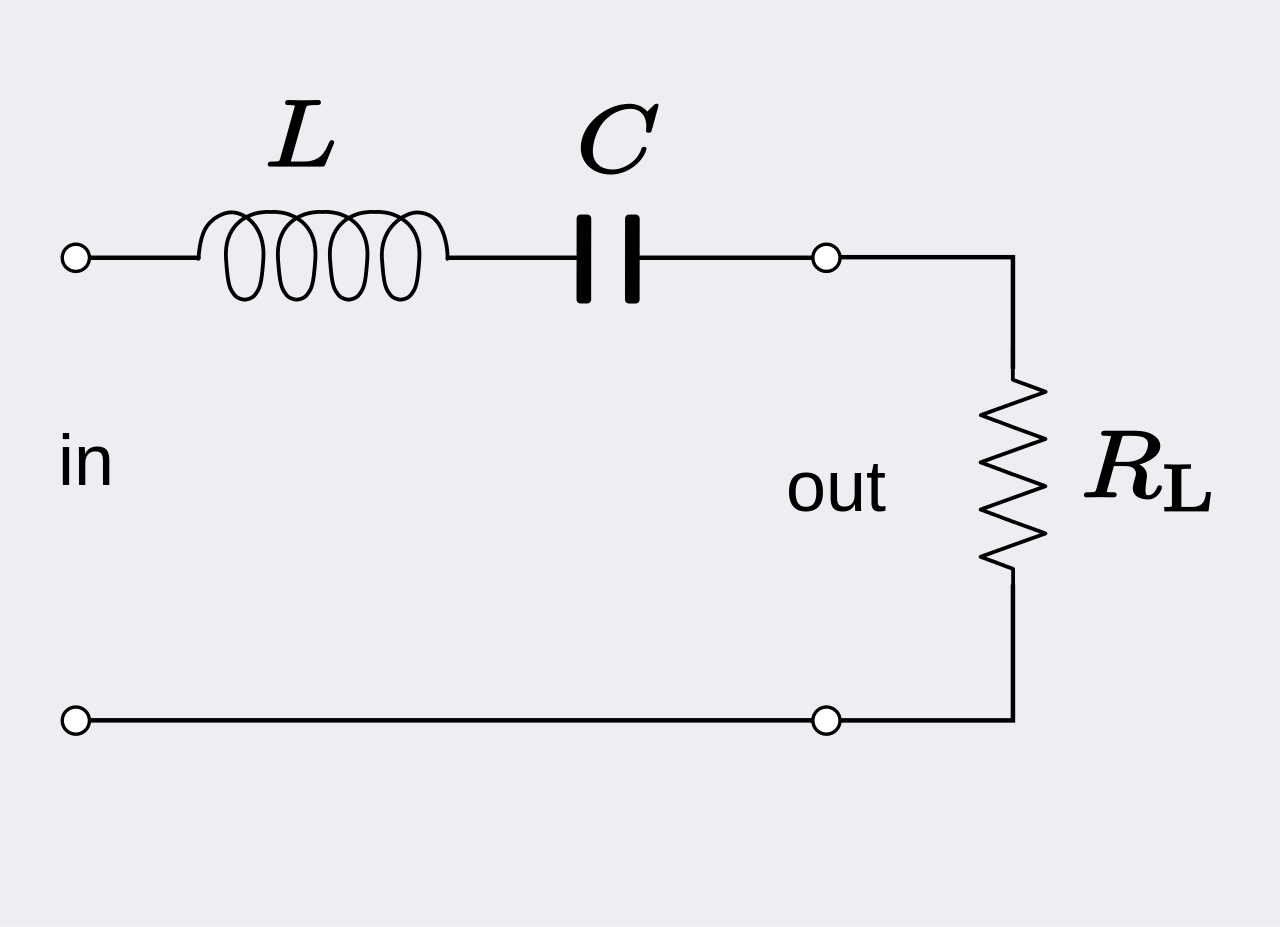
</div>

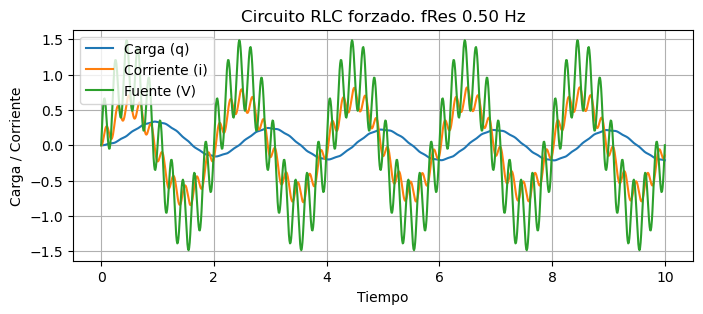

In [12]:
V_values = V*(np.sin(2*np.pi*frec*time_values)+0.5*np.sin(2*np.pi*10*frec*time_values))
q_values, i_values = ResolverCircuito(q0,i0,num_steps,R,L,C,V_values)
Graficar(time_values,q_values,i_values,V_values)

La figura de Lissajous no es ahora un círculo perfecto sino algo mucho más complejo.

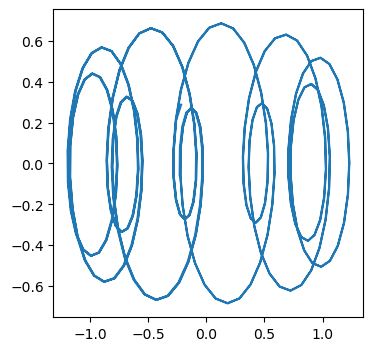

In [13]:
VR, VL = Lissajous()
plt.figure(figsize=(4,4))
plt.plot(VR, VL)
plt.show()

Si usarmos una onda cuadrada, que es una suma infinita de frecuencias (lo vereis en análisis de Fourirer), el efecto es muy notable.

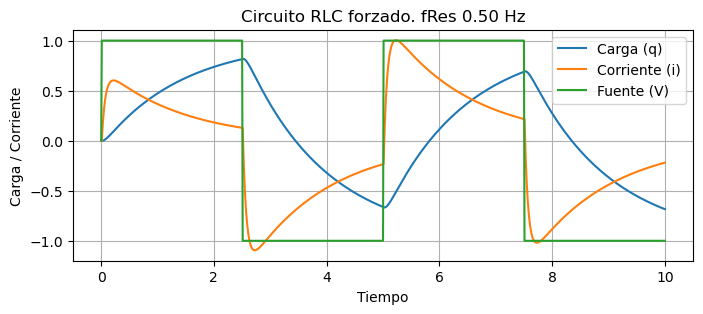

In [14]:
frec=0.2
V_values = V*np.sign(np.sin(2*np.pi*frec*time_values))  # Señal cuadrada
q_values, i_values = ResolverCircuito(q0,i0,num_steps,R,L,C,V_values)
Graficar(time_values,q_values,i_values,V_values)

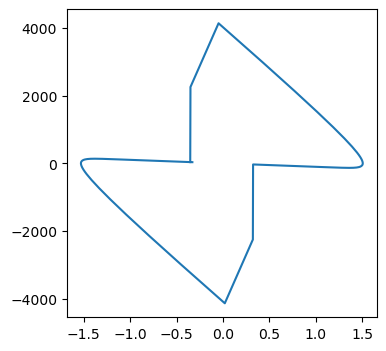

In [23]:
VR, VL = Lissajous()
plt.figure(figsize=(4,4))
plt.plot(VR, VL)
plt.show()

## Descenso de gradiente

El descenso de gradiente es una técnica de optimización para localizar el mínimo de una función, que se ha hecho muy popular por su aplicación en aprendizaje automático. La idea del descenso de gradiente es muy intuititiva. Imagina que estás perdido en la montaña y hay mucha niebla. Una buena estrategia es descender y para ello podemos palpar el suelo con un bastón y hacernos una idea de hacia dónde es más abrupta la pendiente de descenso. Avanzamos unos pasos y repetimos la operación, al final llegaremos a una zona más baja que la inicial.

El descenso de gradiente utiliza el mismo principio, puesto que el gradiente nos da la dirección en las que la derivada de una función de varias variables es máxima. Debemos desplazarnos en la dirección contraria. Para una función de una variable, el gradiente es simplemente la derivada, y el descenso de gradiente puede definirse cómo:

$x(t+1) = x(t)-\alpha \frac{dx}{dt}$

Donde $\alpha$ es la magnitud del "paso".

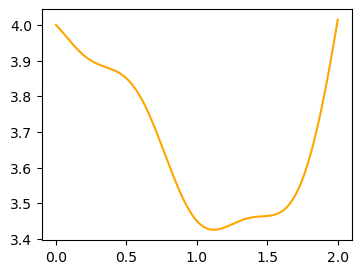

In [24]:
# Encontrar el mínimo de la función y = 4 - x^2 + 0.5 X^3 - 0.05 sin(8x)   entre x=0 y x = 2
import random
liminf = 0
limsup = 2
npunt = 1000                      # El numero de puntos indica el paso mínimo
interv = (limsup-liminf)/npunt
alpha = 10*interv    # Elegimos el paso mínimo
myx = np.linspace(liminf,limsup,npunt)
def myfunc(x):
  return(4 - x**2 + 0.5*x**3 - 0.05*np.sin(8*x))
def mygrad(x):
  return(-2*x + 1.5*x**2-0.4*np.cos(8*x))
y = myfunc(myx)
plt.figure(figsize=(4,3))
plt.plot(myx,y,color="orange")
plt.show()

[1.48796301]


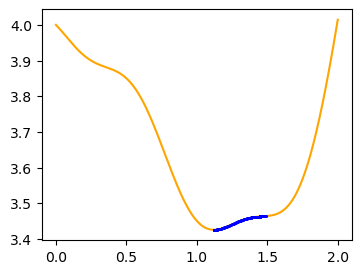

In [36]:
# Elegimos una posición de inicio x al azar.
xini = np.random.uniform(liminf,limsup,1)
print(xini)
epsilon = 0.0000001
diferencia = 1
numpasos = 0
xpos = xini
xdescent = list()
xdescent.append(xini)
pasos = 0
while (diferencia > epsilon):
    xnew = xpos - alpha*mygrad(xpos)
    xdescent.append(xnew)
    diferencia = abs(myfunc(xnew)-myfunc(xpos))
    xpos = xnew

plt.figure(figsize=(4,3))
plt.plot(myx,y,color="orange",markersize=0.1)
plt.plot(xdescent,myfunc(np.array(xdescent)), 'bo',markersize = 1)
plt.show()

## La ecuación del calor

### Numpy gradient

Numpy ofrece la función `gradient` que utiliza derivación numérica por diferencias centrales. Esta función devuelve el valor normalizado, si queremos la derivada hay que multiplicar por $1/h$.

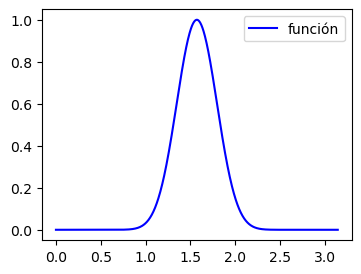

In [37]:
# Veamos otro ejemplo
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

xlength = np.pi
npunt = 1024
x = np.linspace(0,np.pi,npunt)
y = np.sin(x)**20
dx = xlength/(npunt-1)
dt=0.01

plt.figure(figsize=(4,3))
plt.plot(x,y,color="blue",label="función")
plt.legend()
plt.show()

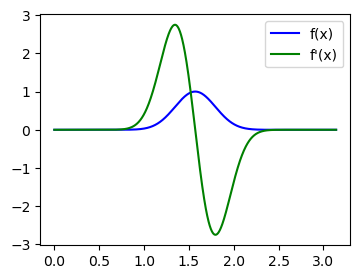

In [38]:
# Para el mismo ejemplo anterior

dygrad = np.gradient(y,dx)
plt.figure(figsize=(4,3))
plt.plot(x,y,color="blue",label="f(x)")
plt.plot(x,dygrad,color="green",label="f'(x)")
plt.legend()
plt.show()

Aparentemente se obtiene el mismo resultado, pero la gráfica puede resultar engañosa, hay que comparar los errores.

Aplicando reiteradamente la función `gradient` se pueden calcular las derivadas de orden superior, teniendo siempre la precaución de comprobar que la función es derivable.

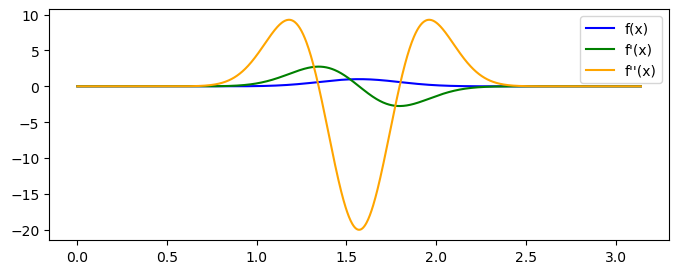

In [20]:
dy2grad = np.gradient(dygrad,dx)         # Derivada segunda
plt.figure(figsize=(8,3))
plt.plot(x,y,color="blue",label="f(x)")
plt.plot(x,dygrad,color="green",label="f'(x)")
plt.plot(x,dy2grad,color="orange",label="f''(x)")
plt.legend()
plt.show()

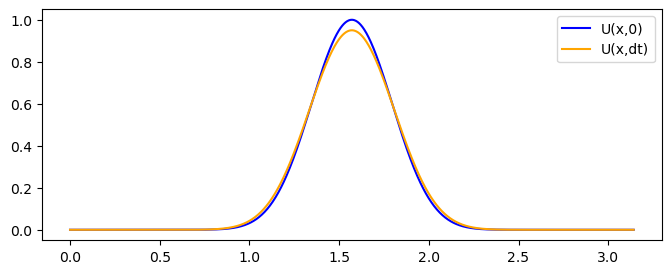

In [21]:
# U(x,t) es la temperatura
# Ut = alpha^2 Uxx
# Vamos a ver el caso unidimensional

y0 = y[:]
U = y0[:]
alpha = 0.5

# Uxx es la segunda derivada que hemos calculado
Ux = dygrad[:]
Uxx = dy2grad[:]
Ut = alpha**2 * Uxx
plt.figure(figsize=(8,3))
plt.plot(x,U,color="blue",label="U(x,0)")
#plt.plot(x,Ut,color="green",label="alpha^2 Uxx(x,0)")
U = U + Ut*dt
y1 = U[:]
plt.plot(x,y1,color="orange",label="U(x,dt)")
plt.legend()
plt.show()

### Resolución de la ecuación diferencial

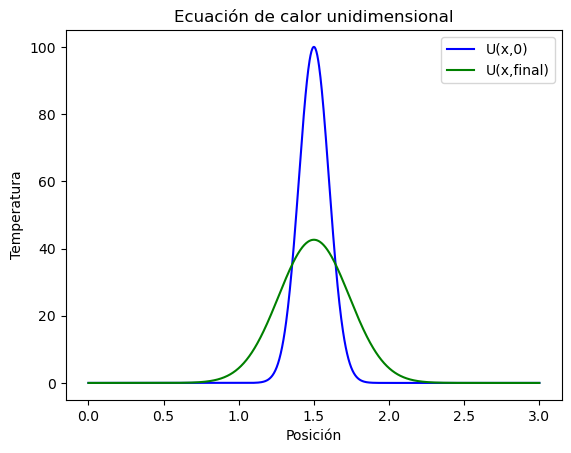

In [22]:
length = 3      # Longitud de la barra
num_points = 1000  # Puntos espaciales
num_steps = 10000  # Pasos de  integración temporal
alpha = 0.5   # Conductividad térmica
Temp0 = 100

x = np.linspace(0, length, num_points)
# Discretization
dx = length / (num_points - 1)
dt = alpha * dx**2

# Condición inicial, pulso gaussiano en mitad de la barra
varianza=0.01
u0= Temp0*np.exp(-(x - 0.5*length)**2 / (2 * varianza))

u = u0
# Bucle de integración
for step in range(num_steps):
    u = u + alpha * np.gradient(np.gradient(u, dx), dx) * dt

# Gráfica
plt.plot(x, u0, color="blue",label="U(x,0)")
plt.plot(x, u, color="green",label="U(x,final)")
plt.title("Ecuación de calor unidimensional")
plt.xlabel("Posición")
plt.ylabel("Temperatura")
plt.legend()
plt.show()

---

<font size="1" color="grey">
    (c) 2023 Javier García Algarra. <a href='https://www.u-tad.com'>www.u-tad.com</a> <br>
Licensed under a Creative Commons Reconocimiento 4.0 Internacional License
</font> 